In [57]:
import pandas as pd
import numpy as np

In [58]:
data = pd.read_csv("merged_tcga_dropped_final.csv")
data

,sample_id,age_at_initial_pathologic_diagnosis,gender,PAM50Call_RNAseq,ER_Status_nature2012,PR_Status_nature2012,HER2_Final_Status_nature2012,OS_Time_nature2012,OS_event_nature2012,final_stage,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-A1-A0SB,70.0,FEMALE,Normal,Positive,Negative,Negative,259.0,0.0,Stage I,...,0.5366,5.2962,1.7015,0.0000,9.1491,13.3508,5.8179,10.5362,4.0283,9.4571
1,TCGA-A1-A0SD,59.0,FEMALE,LumA,Positive,Positive,Negative,437.0,0.0,Stage IIA,...,0.0000,3.6145,4.3589,0.4123,9.3914,12.6757,8.9559,10.7473,8.7529,10.5299
2,TCGA-A1-A0SE,56.0,FEMALE,LumA,Positive,Positive,Negative,1320.0,0.0,Stage I,...,0.7296,0.9907,3.3525,0.0000,9.7743,12.6287,8.0530,11.0453,7.8723,9.8006
3,TCGA-A1-A0SF,54.0,FEMALE,LumA,Positive,Positive,Negative,1463.0,0.0,Stage IIA,...,0.0000,0.8928,4.4016,1.8361,9.3262,12.4998,8.0516,11.5144,7.7695,10.2341
4,TCGA-A1-A0SG,61.0,FEMALE,LumA,Positive,Positive,Negative,433.0,0.0,Stage IIB,...,0.4436,4.2479,3.8032,0.0000,8.9289,12.1010,8.0315,11.3914,7.5616,9.9156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,TCGA-EW-A1PB,70.0,FEMALE,Basal,Negative,Negative,Negative,608.0,0.0,Stage IIIA,...,0.9769,0.0000,6.4457,4.3929,9.6971,12.3131,5.2025,13.0394,3.1285,10.7157
620,TCGA-EW-A1PD,61.0,MALE,LumA,Positive,Positive,Positive,174.0,0.0,Stage IIA,...,0.7443,2.6002,4.0172,0.0000,8.8072,12.8809,9.6391,10.8956,7.9763,10.3861
621,TCGA-EW-A1PE,56.0,FEMALE,LumA,Positive,Positive,Negative,139.0,0.0,Stage IIA,...,0.0000,0.7100,5.4566,0.3982,9.0227,11.9971,8.5217,11.0184,7.4788,10.5293
622,TCGA-EW-A1PF,50.0,FEMALE,LumA,Positive,Positive,Negative,139.0,0.0,Stage IA,...,0.4434,0.4434,4.2744,2.0836,9.3794,12.9027,9.2074,11.2537,7.6644,10.0518


In [59]:
phenotype = data.iloc[:,:10]
phenotype.head()

,sample_id,age_at_initial_pathologic_diagnosis,gender,PAM50Call_RNAseq,ER_Status_nature2012,PR_Status_nature2012,HER2_Final_Status_nature2012,OS_Time_nature2012,OS_event_nature2012,final_stage
0,TCGA-A1-A0SB,70.0,FEMALE,Normal,Positive,Negative,Negative,259.0,0.0,Stage I
1,TCGA-A1-A0SD,59.0,FEMALE,LumA,Positive,Positive,Negative,437.0,0.0,Stage IIA
2,TCGA-A1-A0SE,56.0,FEMALE,LumA,Positive,Positive,Negative,1320.0,0.0,Stage I
3,TCGA-A1-A0SF,54.0,FEMALE,LumA,Positive,Positive,Negative,1463.0,0.0,Stage IIA
4,TCGA-A1-A0SG,61.0,FEMALE,LumA,Positive,Positive,Negative,433.0,0.0,Stage IIB


“The first 10 columns represent phenotype information (patient demographics, receptor status, stage, etc.). This subset will be used for clinical stratification.”  

In [60]:
survival = pd.concat(
    [data[["sample_id"]], data.iloc[:, 10:18]],
    axis=1
)
survival

,sample_id,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time
0,TCGA-A1-A0SB,0.0,259.0,0.0,259.0,0.0,259.0,0.0,259.0
1,TCGA-A1-A0SD,0.0,437.0,0.0,437.0,0.0,437.0,0.0,437.0
2,TCGA-A1-A0SE,0.0,1321.0,0.0,1321.0,0.0,1321.0,0.0,1321.0
3,TCGA-A1-A0SF,0.0,1463.0,0.0,1463.0,0.0,1463.0,0.0,1463.0
4,TCGA-A1-A0SG,0.0,434.0,0.0,434.0,0.0,434.0,0.0,434.0
...,...,...,...,...,...,...,...,...,...
619,TCGA-EW-A1PB,0.0,608.0,0.0,608.0,0.0,608.0,0.0,608.0
620,TCGA-EW-A1PD,0.0,424.0,0.0,424.0,0.0,424.0,0.0,424.0
621,TCGA-EW-A1PE,0.0,320.0,0.0,320.0,0.0,320.0,0.0,320.0
622,TCGA-EW-A1PF,0.0,439.0,0.0,439.0,0.0,439.0,0.0,439.0


In [61]:
gene = pd.concat(
    [data[["sample_id"]], data.iloc[:, 18:]],
    axis=1
)
gene

,sample_id,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-A1-A0SB,10.8075,6.0416,0.5366,11.8120,11.3068,9.9874,12.9785,2.7775,0.0000,...,0.5366,5.2962,1.7015,0.0000,9.1491,13.3508,5.8179,10.5362,4.0283,9.4571
1,TCGA-A1-A0SD,9.1657,2.4935,0.0000,11.7868,11.0131,10.5228,12.8109,4.6140,0.0000,...,0.0000,3.6145,4.3589,0.4123,9.3914,12.6757,8.9559,10.7473,8.7529,10.5299
2,TCGA-A1-A0SE,9.7179,3.3983,0.0000,11.3219,11.2617,10.3831,12.5342,4.1789,0.0000,...,0.7296,0.9907,3.3525,0.0000,9.7743,12.6287,8.0530,11.0453,7.8723,9.8006
3,TCGA-A1-A0SF,9.8581,4.9132,0.0000,11.4817,11.0700,10.2721,12.7637,3.3820,0.0000,...,0.0000,0.8928,4.4016,1.8361,9.3262,12.4998,8.0516,11.5144,7.7695,10.2341
4,TCGA-A1-A0SG,10.1198,1.6599,0.0000,11.8184,11.0909,10.2251,12.7285,3.0356,0.4436,...,0.4436,4.2479,3.8032,0.0000,8.9289,12.1010,8.0315,11.3914,7.5616,9.9156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,TCGA-EW-A1PB,10.2943,5.7529,0.7184,11.9483,11.2539,10.6590,11.4662,4.5797,0.4035,...,0.9769,0.0000,6.4457,4.3929,9.6971,12.3131,5.2025,13.0394,3.1285,10.7157
620,TCGA-EW-A1PD,9.6299,2.8903,0.0000,11.5684,11.7729,10.5613,12.2339,4.9246,0.0000,...,0.7443,2.6002,4.0172,0.0000,8.8072,12.8809,9.6391,10.8956,7.9763,10.3861
621,TCGA-EW-A1PE,10.0013,2.3597,0.0000,11.9291,10.9019,10.7520,12.0835,1.9490,0.7100,...,0.0000,0.7100,5.4566,0.3982,9.0227,11.9971,8.5217,11.0184,7.4788,10.5293
622,TCGA-EW-A1PF,9.6384,2.9025,0.0000,12.1853,11.7110,10.4224,12.5523,4.8252,0.0000,...,0.4434,0.4434,4.2744,2.0836,9.3794,12.9027,9.2074,11.2537,7.6644,10.0518


In [62]:
gene.shape

(624, 20531)

In [83]:
gene.describe()

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
count,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,...,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000
mean,9.556519,2.759373,0.253329,11.870518,11.189569,10.492332,12.598326,4.159710,0.290477,5.332108,...,0.550202,2.856709,4.163729,0.686579,9.379230,12.127355,8.006771,10.982651,6.059767,10.103863
std,0.630199,1.874883,0.716950,0.342559,0.464745,0.428321,0.493149,1.152119,0.428025,1.043760,...,0.609454,2.676484,0.838343,1.190334,0.504378,0.996179,0.796350,0.608146,2.228386,0.538804
min,7.434600,0.000000,0.000000,10.778800,9.773100,9.035500,11.325500,0.000000,0.000000,1.700700,...,0.000000,0.000000,0.669300,0.000000,7.222300,7.222100,4.903200,9.167300,0.000000,8.679300
25%,9.148375,1.300800,0.000000,11.648625,10.897850,10.213250,12.283062,3.387700,0.000000,4.723525,...,0.000000,0.546325,3.618500,0.000000,9.083700,11.541200,7.545400,10.656475,4.841400,9.749713
50%,9.543725,2.385550,0.000000,11.857800,11.223200,10.500650,12.589250,4.180250,0.000000,5.345050,...,0.429800,2.183500,4.143025,0.000000,9.343150,12.237100,8.028900,10.997125,6.497300,10.036700
75%,9.929112,4.033862,0.000000,12.085950,11.508850,10.761200,12.898075,4.827750,0.459950,6.035150,...,0.868775,4.614525,4.665425,0.900562,9.601938,12.837400,8.509050,11.352950,7.711100,10.399350
max,11.722100,9.257300,7.729900,13.046900,13.527300,11.986300,14.340800,9.513200,2.297900,8.629500,...,3.491100,11.337700,6.617400,5.291300,11.989100,14.876600,10.311000,13.039400,10.092600,12.285400


Text(0.5, 1.0, 'Variance Distribution across patients')

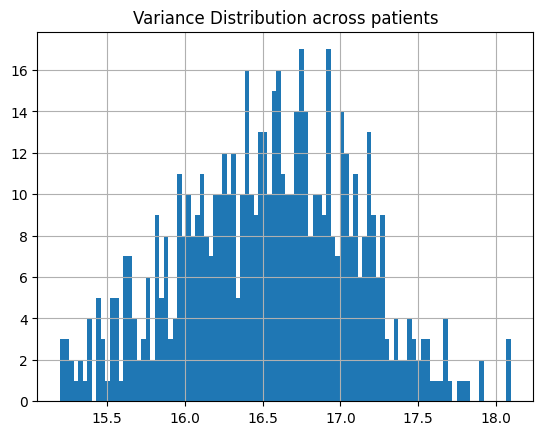

In [84]:
import matplotlib.pyplot as plt

gene.iloc[:,1:].var(axis=1).hist(bins=100)
plt.title("Variance Distribution across patients")

The distribution of variance across patients appears approximately normal, indicating that most patients exhibit similar levels of overall gene expression variability. This suggests the absence of extreme outlier samples and supports the consistency of the dataset.

Text(0.5, 1.0, 'Variance Distribution across genes')

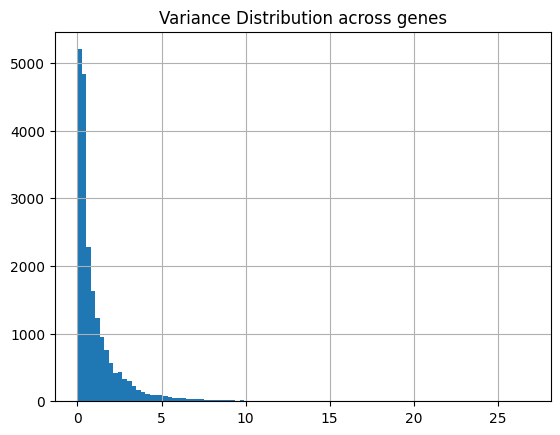

In [85]:
gene.iloc[:,1:].var(axis=0).hist(bins=100)
plt.title("Variance Distribution across genes")

Interpretation of the right‑skewed variance distribution

* Most genes: Cluster near very low variance values (close to 0). This means their expression levels are fairly stable across patients.
* Few genes: Sit in the long right tail with much higher variance. These are the ones contributing disproportionately to variability in the dataset.
* Skewed shape: The histogram shows a classic “many stable, few variable” pattern, which is common in gene expression data.

In [9]:
phenotype.columns

Index(['sample_id', 'age_at_initial_pathologic_diagnosis', 'gender',
       'PAM50Call_RNAseq', 'ER_Status_nature2012', 'PR_Status_nature2012',
       'HER2_Final_Status_nature2012', 'OS_Time_nature2012',
       'OS_event_nature2012', 'final_stage'],
      dtype='object')

In [10]:
survival.columns

Index(['sample_id', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time',
       'PFI', 'PFI.time'],
      dtype='object')

### Subtype

In [11]:
phenotype['PAM50Call_RNAseq'].value_counts()

PAM50Call_RNAseq
LumA      306
LumB      145
Basal     108
Her2       51
Normal     14
Name: count, dtype: int64

In [12]:
phenotype['PAM50Call_RNAseq'].value_counts(normalize=True) * 100

PAM50Call_RNAseq
LumA      49.038462
LumB      23.237179
Basal     17.307692
Her2       8.173077
Normal     2.243590
Name: proportion, dtype: float64

1. “The dataset shows class imbalance, with Luminal A being dominant.”
2. “Minor subtypes like HER2 are underrepresented.”
3. This reflects real biological prevalence OR dataset bias
4. Why it matters: Clustering may be biased toward dominant subtype, Rare subtypes may not form clear clusters

<Axes: xlabel='PAM50Call_RNAseq', ylabel='count'>

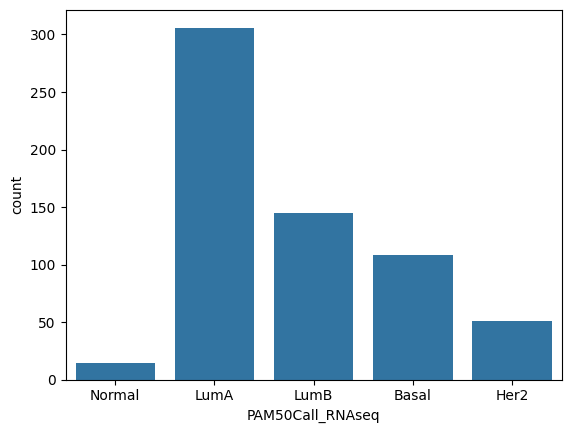

In [17]:
sns.countplot(x='PAM50Call_RNAseq', data=phenotype)  

In [18]:
phenotype['OS_event_nature2012'].value_counts(normalize=True) * 100

OS_event_nature2012
0.0    95.032051
1.0     4.967949
Name: proportion, dtype: float64

### stage

In [19]:
phenotype['final_stage'].value_counts(normalize=True)*100

final_stage
Stage IIA        35.576923
Stage IIB        23.076923
Stage IIIA       15.384615
Stage I           9.294872
Stage IA          7.852564
Stage IIIC        4.006410
Stage IIIB        2.243590
Stage X           1.442308
Stage IB          0.480769
[Discrepancy]     0.480769
Stage II          0.160256
Name: proportion, dtype: float64

* “Most patients are in intermediate stages (Stage IIA/IIB/IIIA).”
* “Early-stage and late-stage patients are less represented.”
* Tumor stage distribution indicates that most patients fall within intermediate stages, suggesting a heterogeneous disease progression within the cohort.
* Why it matters: Survival trends depend on stage, Clusters may reflect stage differences.

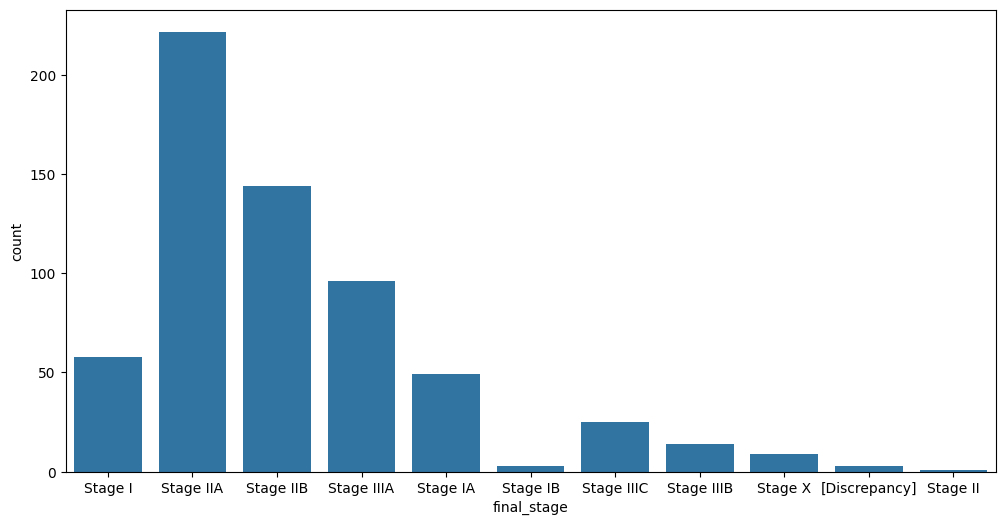

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6)) 
sns.countplot(x='final_stage', data=phenotype)
plt.show()

### Receptors

To understand receptor distributions in the cohort, I visualize ER, PR, and HER2 status counts.

<Axes: xlabel='ER_Status_nature2012', ylabel='count'>

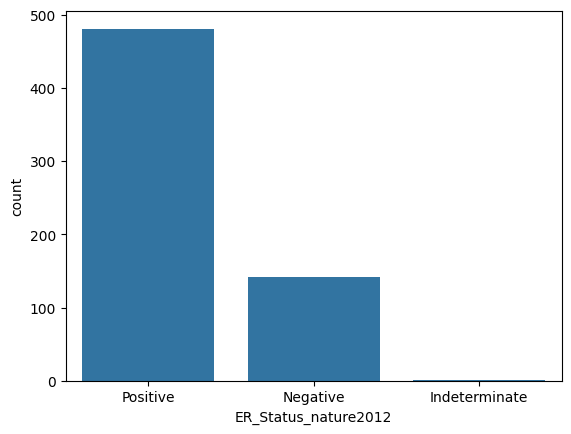

In [21]:
sns.countplot(x='ER_Status_nature2012', data=phenotype)

<Axes: xlabel='PR_Status_nature2012', ylabel='count'>

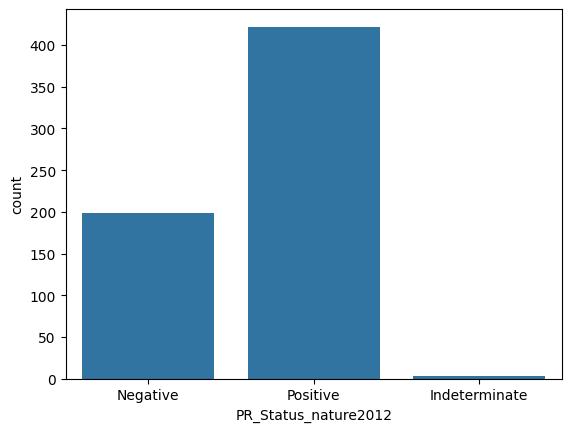

In [22]:
sns.countplot(x='PR_Status_nature2012', data=phenotype)

<Axes: xlabel='HER2_Final_Status_nature2012', ylabel='count'>

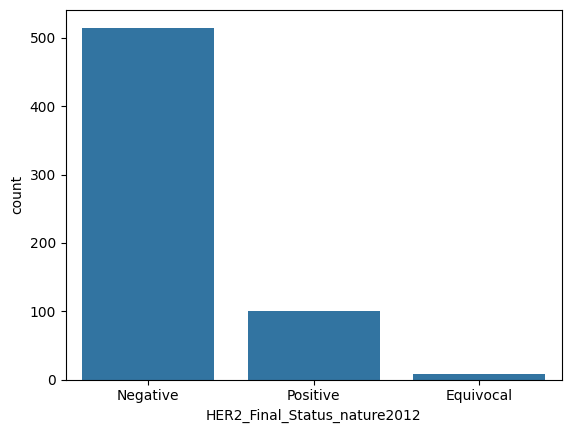

In [23]:
sns.countplot(x='HER2_Final_Status_nature2012', data=phenotype)

The cohort is predominantly ER-positive and PR-positive, indicating a high prevalence of hormone receptor–positive breast cancers. In contrast, HER2-negative cases constitute the majority, with a smaller proportion of HER2-positive tumors, reflecting typical breast cancer subtype distributions. These patterns matter clinically: ER/PR‑positive tumors respond to hormone therapy, while HER2‑positive ones need targeted treatment. Indeterminate or equivocal cases are rare, so receptor classification is clear for downstream analysis.

In [24]:
pd.crosstab(phenotype['PAM50Call_RNAseq'], phenotype['final_stage'])

final_stage,Stage I,Stage IA,Stage IB,Stage II,Stage IIA,Stage IIB,Stage IIIA,Stage IIIB,Stage IIIC,Stage X,[Discrepancy]
PAM50Call_RNAseq,,,,,,,,,,,
Basal,9,9,0,0,51,22,11,1,3,2,0
Her2,1,1,0,0,22,12,8,1,4,2,0
LumA,38,31,2,1,98,69,45,5,10,4,3
LumB,8,8,1,0,46,36,30,7,8,1,0
Normal,2,0,0,0,5,5,2,0,0,0,0


1. Luminal A is the most prevalent subtype across all tumor stages, indicating that it represents the dominant molecular class in this cohort.
2. The majority of patients are concentrated in intermediate to advanced stages (Stage II and III), suggesting a heterogeneous but progression-skewed cohort.
3. More aggressive subtypes such as Basal and HER2-enriched appear more frequently in higher stages, suggesting an association between subtype and disease progression.
4. Luminal B subtype shows a tendency toward higher stages compared to Luminal A, indicating relatively more aggressive clinical behavior.
5. The Normal-like subtype is minimally represented, limiting its contribution to downstream analysis.
6. Early-stage tumors are less represented in the dataset, which may influence clustering toward patterns associated with more advanced disease.

<Axes: xlabel='age_at_initial_pathologic_diagnosis', ylabel='Count'>

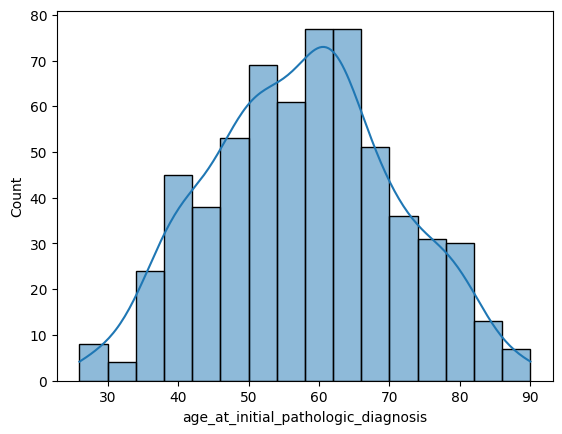

In [25]:
sns.histplot(phenotype['age_at_initial_pathologic_diagnosis'], kde=True)

1. “The age at diagnosis follows an approximately normal distribution centered around 55–65 years, indicating no significant skewness or extreme outliers.”

2. Most patients fall in mid-age range
Majority between 45–70 years.
Very few:
very young (<35),
very old (>85)

4. “This distribution is consistent with known epidemiology of breast cancer, which is more prevalent in middle-aged and older individuals.”

<Axes: xlabel='OS_Time_nature2012', ylabel='Count'>

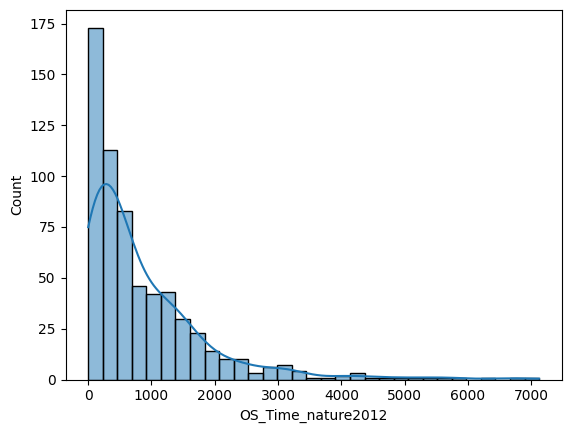

In [26]:
sns.histplot(phenotype['OS_Time_nature2012'], kde=True)

<Axes: xlabel='OS.time', ylabel='Count'>

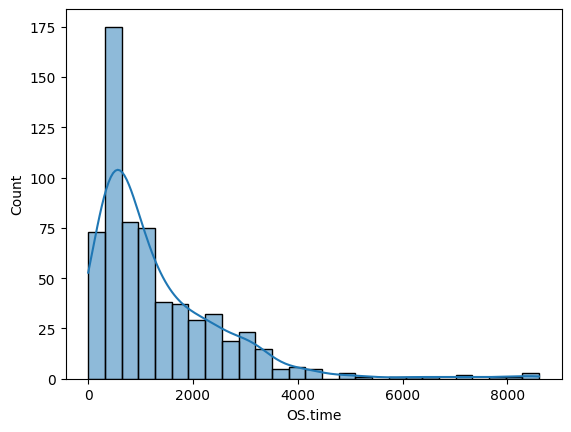

In [27]:
sns.histplot(survival['OS.time'], kde=True)

<Axes: xlabel='PFI.time', ylabel='Count'>

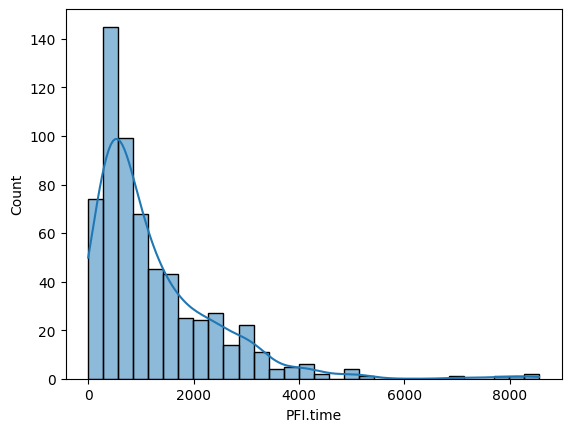

In [28]:
sns.histplot(survival['PFI.time'], kde=True)

In [29]:
survival['OS'].value_counts(normalize=True)*100

OS
0.0    92.788462
1.0     7.211538
Name: proportion, dtype: float64

1. Age → approximately normal
2. Survival / time variables → right-skewed
3. Most clinical time-to-event variables showed right-skewed distributions, while age followed an approximately normal distribution.
4. Many patients have low/medium survival time
5. Few patients have very high survival time (long tail)

## COMBINED CLINICAL + SURVIVAL EDA

In [30]:
phen_survival = phenotype.merge(survival, on='sample_id')

### Subtype vs Survival

<Axes: xlabel='PAM50Call_RNAseq', ylabel='OS_Time_nature2012'>

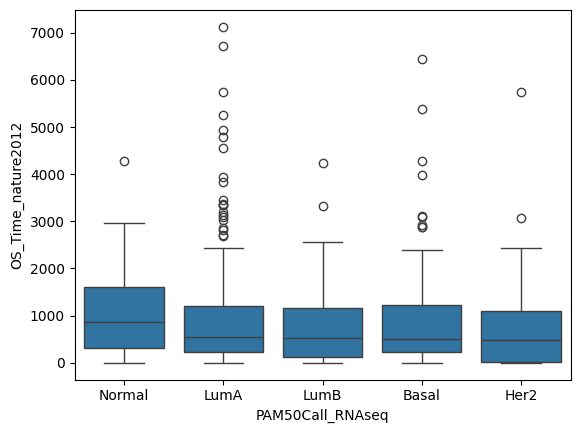

In [39]:
sns.boxplot(x='PAM50Call_RNAseq', y='OS_Time_nature2012', data=phen_survival)

* Survival distributions vary across molecular subtypes, indicating that subtype classification may be associated with patient prognosis
* Luminal A subtype appears to have relatively better survival outcomes, consistent with its known less aggressive biological behavior.
* Basal and HER2 subtypes exhibit greater variability in survival, suggesting heterogeneous clinical outcomes (Presence of both low and high survival patients) within these groups.
* Several high-value outliers are observed, representing long-term survivors. These are biologically meaningful and are retained for further analysis.
* Despite observable trends, substantial overlap exists between subtype survival distributions, indicating that subtype alone may not fully explain survival variability.

### Stage vs Survival

<Axes: xlabel='final_stage', ylabel='OS_Time_nature2012'>

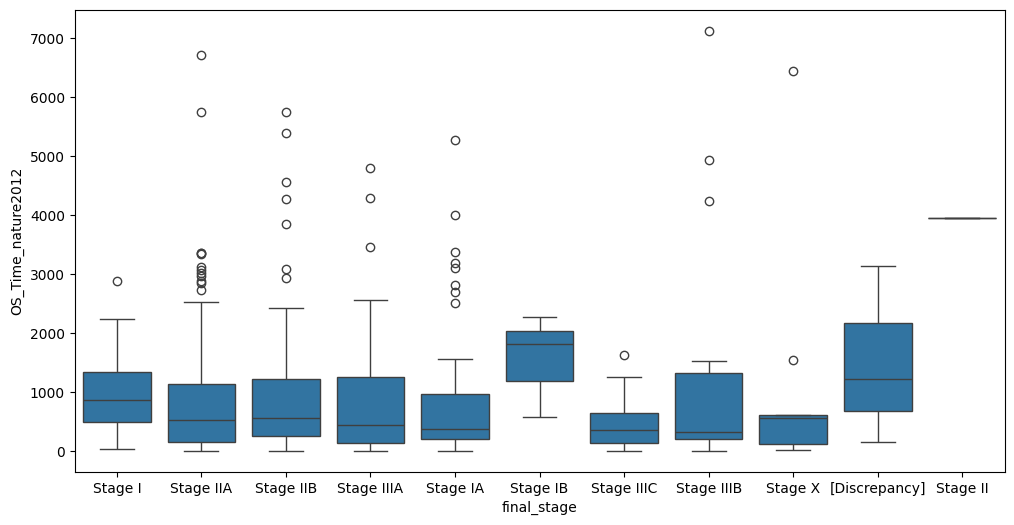

In [40]:
plt.figure(figsize=(12,6)) 
sns.boxplot(x='final_stage', y='OS_Time_nature2012', data=phen_survival)

* **Trend:** Survival generally **decreases with increasing stage**, but not perfectly monotonic.
* **Best outcomes:** **Stage IB and early stages (I)** show **higher median survival**.
* **Intermediate stages (IIA, IIB, II):** **Moderate medians with large variability** → heterogeneous patient outcomes.
* **Advanced stages (IIIA–IIIC):** **Lower medians**, especially **IIIC**, indicating poorer prognosis.
* **Outliers:** Present across all stages (very long survival) → possible **exceptional responders or censored data**.
* **Special labels (Stage X / Discrepancy):** Noisy, wide spread → **handle cautiously or exclude**.

👉 **Conclusion:** Stage impacts survival, but **high overlap and variance mean other features are essential for prediction**.


In [53]:
# Remove rows with Stage X or Discrepancy
data_2 = data[~data['final_stage'].isin(['Stage X', 'Discrepancy'])]

In [56]:
data_2.to_csv("eda_modified_data.csv", index=False)

### Age vs Survival

## CORRELATION ANALYSIS

<Axes: >

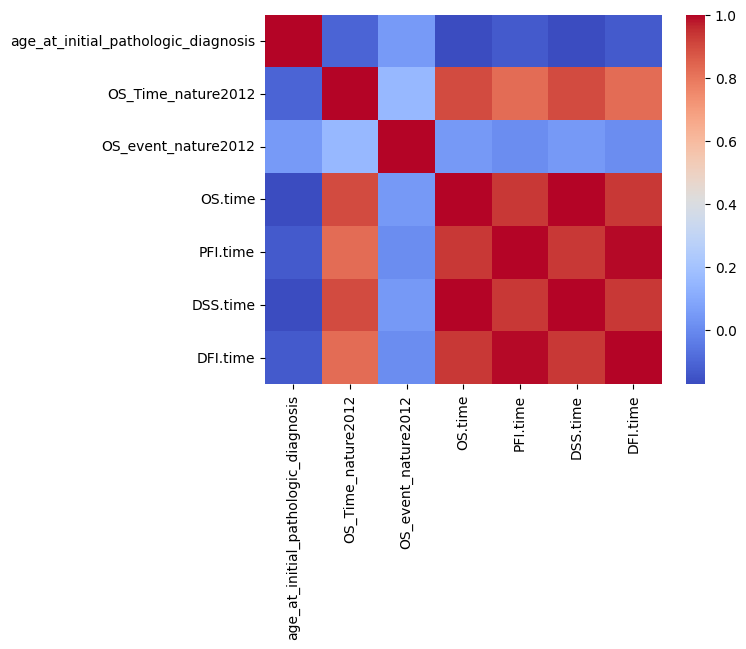

In [36]:
sns.heatmap(phen_survival[['age_at_initial_pathologic_diagnosis',
    'OS_Time_nature2012',
    'OS_event_nature2012',
    'OS.time',
    'PFI.time',
    'DSS.time',
    'DFI.time']].corr(), cmap='coolwarm')

“Correlation analysis shows predominantly positive relationships among survival-related variables, which is expected as different survival metrics are inherently related.”

<Axes: xlabel='age_at_initial_pathologic_diagnosis', ylabel='OS_Time_nature2012'>

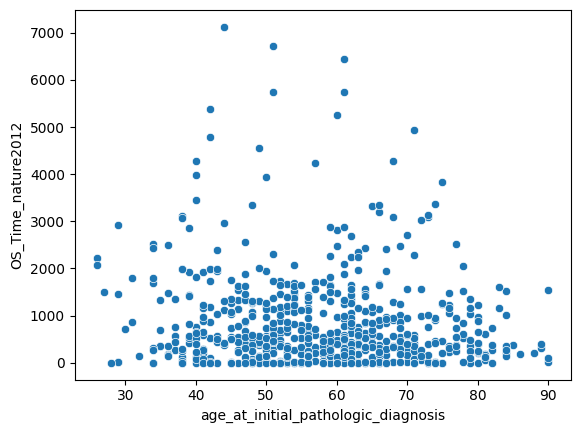

In [38]:
import seaborn as sns

sns.scatterplot(
    x='age_at_initial_pathologic_diagnosis',
    y='OS_Time_nature2012',
    data=phen_survival
)

In [37]:
phen_survival[['age_at_initial_pathologic_diagnosis',
      'OS_Time_nature2012']].corr()

,age_at_initial_pathologic_diagnosis,OS_Time_nature2012
age_at_initial_pathologic_diagnosis,1.000000,-0.105027
OS_Time_nature2012,-0.105027,1.000000


1. “Although age is expected to negatively influence survival, the observed relationship is weak, indicating that other clinical and molecular factors play a more dominant role.”

2. “Age may show a weak negative correlation(-0.1) with survival, but survival outcomes in cancer are influenced by multiple interacting factors, so the relationship is not strongly linear.”

### OUTLIER CHECK

<Axes: ylabel='OS_Time_nature2012'>

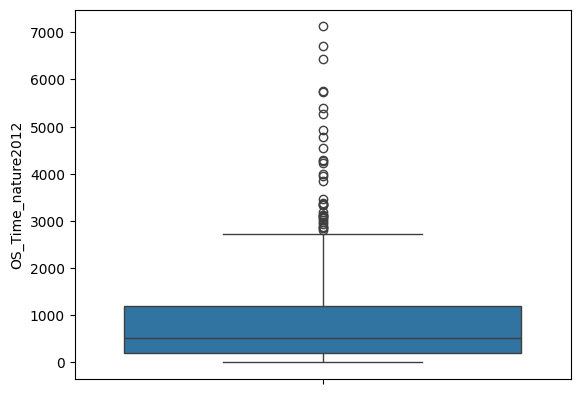

In [41]:
sns.boxplot(y=phenotype['OS_Time_nature2012'])

“Outliers in survival time were retained as they represent true clinical variability rather than noise.”

<Axes: ylabel='age_at_initial_pathologic_diagnosis'>

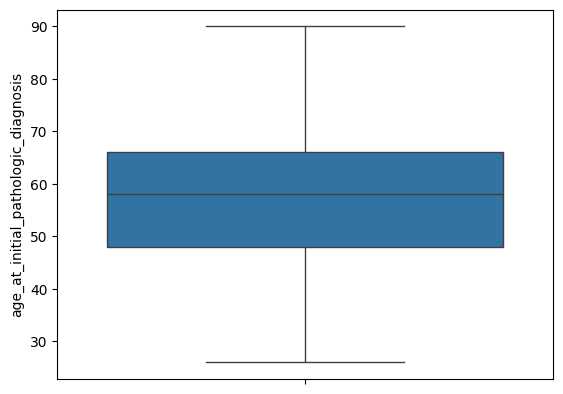

In [42]:
sns.boxplot(y=phenotype['age_at_initial_pathologic_diagnosis'])

<Axes: xlabel='timeline'>

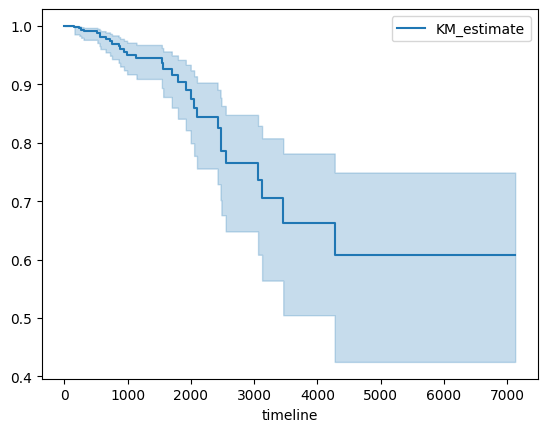

In [44]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(data['OS_Time_nature2012'], event_observed=data['OS_event_nature2012'])
kmf.plot()

What this plot shows?

🔹 X-axis → Time (days) Survival duration - e.g., 0 → 7000 days (~19 years)

🔹 Y-axis → Survival Probability (Probability of being alive at that time)

Starts at 1 (100%)

📉 The curve (blue line) Step-like decreasing curve Drops whenever a death event occurs

👉 Example:

At ~3000 days → survival ≈ 0.75

At ~7000 days → survival ≈ 0.60

🔹 Shaded region (IMPORTANT)
This is the confidence interval (CI), Shows uncertainty in estimation

👉 Wider at later times because:

Fewer patients remain
Less reliable estimate

✔ Survival decreases gradually

→ Not an aggressive drop

✔ Around 60% survival at long time

→ Moderate prognosis

✔ Large uncertainty at tail

→ Few patients → less confidence

This plot estimates the survival function over time. The stepwise drops correspond to death events, and the shaded region represents confidence intervals, which widen as fewer patients remain under observation

## Final Conclusion

Exploratory data analysis revealed significant heterogeneity in both gene expression and clinical variables. A subset of genes exhibited high variability across patients, indicating the presence of informative molecular features. Clinical variables such as tumor stage and molecular subtype showed observable associations with survival outcomes, although substantial overlap suggests that these factors alone are insufficient for precise patient stratification. These findings motivate the need for feature selection and dimensionality reduction to identify meaningful patterns in high-dimensional gene expression data, followed by clustering to uncover distinct patient subgroups.